# Demand Forecasting with Gradient-Boosted Trees (real Rossmann data)

Predicting daily store sales from historical data — the kind of problem that drives
inventory and selection decisions in large-scale retail.

**Why this is built the way it is**
- It uses **lag + rolling-window features** so a tree model can learn temporal structure.
- It uses a **time-aware train/validation split** (never shuffled) and **past-only** features,
  so there is no data leakage — the single most common mistake in forecasting projects.
- It always reports performance **relative to a seasonal-naive baseline**. The headline is
  not "my RMSE is X", it is "I beat the naive forecast by Y%", which is what proves the
  model actually adds value.

> **Using real data:** the data here is generated to mirror the Kaggle *Rossmann Store Sales*
> dataset. To run on the real thing, point `DATA_PATH` at Rossmann's `train.csv` — it already
> has `Store, Date, Sales, Promo, Open` columns, so nothing else changes.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.1f}")
RNG = np.random.default_rng(42)

## 1. Load the real Rossmann data

This reads the actual Kaggle **Rossmann Store Sales** files. Put `train.csv` (required) and
`store.csv` (optional, for `StoreType`) in the same folder as this notebook.

Rossmann's columns differ slightly from a generic sales table, so this cell translates them
into what the rest of the pipeline expects (`Store, Date, Sales, Promo, Open, StoreType,
IsHoliday`): holidays come from `StateHoliday` + `SchoolHoliday`, and `StoreType` is merged
in from `store.csv`. Everything downstream is unchanged.

In [2]:
# === Load the REAL Rossmann data (from Kaggle "Rossmann Store Sales") ===
train = pd.read_csv("train.csv", parse_dates=["Date"], low_memory=False)

# StoreType lives in store.csv; merge it in if the file is present, else use a constant.
try:
    store = pd.read_csv("store.csv")
    train = train.merge(store[["Store", "StoreType"]], on="Store", how="left")
except FileNotFoundError:
    train["StoreType"] = "a"

# Build one IsHoliday flag from Rossmann's StateHoliday ('0'=none; a/b/c=holiday) + SchoolHoliday
if "StateHoliday" in train.columns:
    state_hol = train["StateHoliday"].astype(str) != "0"
else:
    state_hol = pd.Series(False, index=train.index)
if "SchoolHoliday" in train.columns:
    school_hol = train["SchoolHoliday"].fillna(0).astype(int) == 1
else:
    school_hol = pd.Series(False, index=train.index)
train["IsHoliday"] = (state_hol | school_hol).astype(int)

# Keep exactly the columns the pipeline expects
df = train[["Store", "Date", "Sales", "Promo", "Open", "StoreType", "IsHoliday"]].copy()
df["StoreType"] = df["StoreType"].fillna("a")

print(f"{len(df):,} rows | {df.Store.nunique()} stores | "
      f"{df.Date.min().date()} -> {df.Date.max().date()}")
df.head()

1,017,209 rows | 1115 stores | 2013-01-01 -> 2015-07-31


,Store,Date,Sales,Promo,Open,StoreType,IsHoliday
0,1,2015-07-31,5263,1,1,c,1
1,2,2015-07-31,6064,1,1,a,1
2,3,2015-07-31,8314,1,1,a,1
3,4,2015-07-31,13995,1,1,c,1
4,5,2015-07-31,4822,1,1,a,1


## 2. Quick look at the data

Average sales by day of week and by month — you should see the weekend lift and the
year-end holiday peak that we baked in. This is also where SOP / interview talking points
come from.

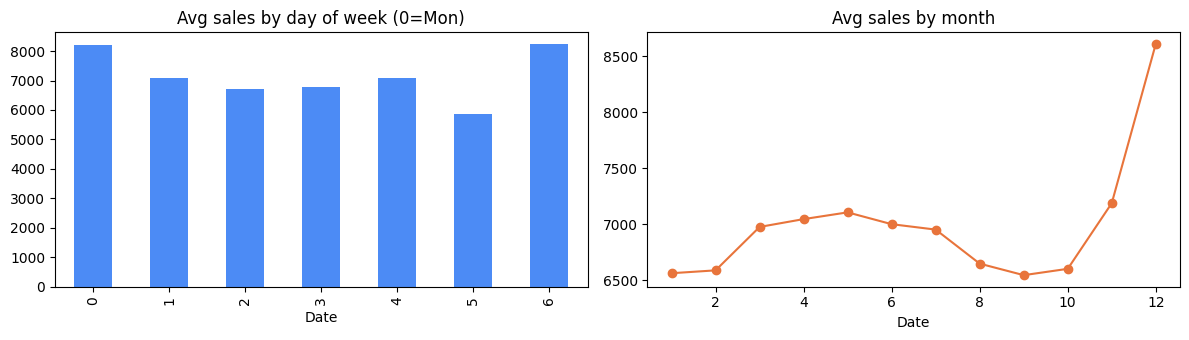

In [3]:
open_df = df[df.Open == 1]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
open_df.groupby(open_df.Date.dt.dayofweek).Sales.mean().plot(
    kind="bar", ax=ax[0], color="#4C8BF5", title="Avg sales by day of week (0=Mon)")
open_df.groupby(open_df.Date.dt.month).Sales.mean().plot(
    marker="o", ax=ax[1], color="#E8743B", title="Avg sales by month")
plt.tight_layout(); plt.show()

## 3. Feature engineering

Two kinds of features:
- **Calendar** parts (day of week, month, week of year, weekend / month-edge flags).
- **Temporal** features — the important ones: `lag_{7,14,28}` (sales N days ago) and
  rolling mean / std over the past 7 and 30 days.

Both are computed **per store** and **shifted into the past** (`shift(1)` before rolling), so
a row never sees its own or any future value. That is what keeps the validation honest.

In [4]:
def build_features(df):
    df = df[(df.Open == 1) & (df.Sales > 0)].sort_values(["Store", "Date"]).reset_index(drop=True)
    d = df.Date.dt
    df["dayofweek"]=d.dayofweek; df["day"]=d.day; df["month"]=d.month
    df["year"]=d.year; df["weekofyear"]=d.isocalendar().week.astype(int)
    df["is_weekend"]=(df.dayofweek>=5).astype(int)
    df["is_month_start"]=d.is_month_start.astype(int)
    df["is_month_end"]=d.is_month_end.astype(int)

    g = df.groupby("Store").Sales
    for lag in (7,14,28): df[f"lag_{lag}"] = g.shift(lag)
    shifted = g.shift(1)
    for w in (7,30):
        r = shifted.groupby(df.Store).rolling(w)
        df[f"roll_mean_{w}"] = r.mean().reset_index(level=0, drop=True)
        df[f"roll_std_{w}"]  = r.std().reset_index(level=0, drop=True)

    df["StoreType"] = df.StoreType.astype("category").cat.codes
    return df.dropna().reset_index(drop=True)

data = build_features(df)
print(f"{len(data):,} rows after feature build")
data.head()

810,888 rows after feature build


,Store,Date,Sales,Promo,Open,StoreType,IsHoliday,dayofweek,day,month,...,is_weekend,is_month_start,is_month_end,lag_7,lag_14,lag_28,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30
0,1,2013-02-06,6140,1,1,2,0,2,6,2,...,0,0,0,"3,725.0","5,394.0","4,486.0","5,388.4","1,109.4","5,103.8",852.2
1,1,2013-02-07,5499,1,1,2,0,3,7,2,...,0,0,0,"4,601.0","5,720.0","4,997.0","5,733.4",851.4,"5,124.2",869.8
2,1,2013-02-08,5681,1,1,2,0,4,8,2,...,0,0,0,"4,709.0","5,578.0","7,176.0","5,861.7",707.9,"5,163.2",859.0
3,1,2013-02-09,5370,0,1,2,0,5,9,2,...,1,0,0,"5,633.0","5,195.0","5,580.0","6,000.6",512.4,"5,203.1",854.2
4,1,2013-02-11,4409,0,1,2,0,0,11,2,...,0,0,0,"5,970.0","5,586.0","5,471.0","5,963.0",552.0,"5,215.5",853.8


## 4. Time-aware split

Hold out the **most recent 6 weeks** for validation and train on everything before. We never
shuffle — that would let the model peek at the future.

In [5]:
VALID_WEEKS = 6
cutoff = data.Date.max() - pd.Timedelta(weeks=VALID_WEEKS)
train = data[data.Date <= cutoff]
valid = data[data.Date >  cutoff]
print(f"cutoff {cutoff.date()} | train {len(train):,} | valid {len(valid):,}")

FEATURES = ["Promo","IsHoliday","StoreType","dayofweek","day","month","year",
            "weekofyear","is_weekend","is_month_start","is_month_end",
            "lag_7","lag_14","lag_28","roll_mean_7","roll_std_7",
            "roll_mean_30","roll_std_30"]
Xtr, ytr = train[FEATURES], train.Sales.to_numpy()
Xva, yva = valid[FEATURES], valid.Sales.to_numpy()

cutoff 2015-06-19 | train 770,606 | valid 40,282


## 5. Baseline + model

**Baseline:** seasonal-naive — predict the same weekday last week (`lag_7`). Any real model
has to beat this to be worth anything.

**Model:** scikit-learn `HistGradientBoostingRegressor` (histogram-based gradient-boosted trees — the same family as LightGBM/XGBoost, but ships inside scikit-learn with no extra system libraries).

In [6]:
def rmse(y,p): return float(np.sqrt(np.mean((y-p)**2)))
def mae(y,p):  return float(np.mean(np.abs(y-p)))
def mape(y,p):
    m = y > 0; return float(np.mean(np.abs((y[m]-p[m])/y[m]))*100)

base_pred = valid.lag_7.to_numpy()

model = HistGradientBoostingRegressor(
    loss="squared_error", max_iter=500, learning_rate=0.05,
    max_leaf_nodes=63, min_samples_leaf=50, l2_regularization=1.0,
    random_state=42)
model.fit(Xtr, ytr)
model_pred = np.clip(model.predict(Xva), 0, None)
print("trees built:", model.n_iter_)

trees built: 500


## 6. Results — always vs. the baseline

In [7]:
res = pd.DataFrame([
    {"model":"Seasonal-naive baseline","RMSE":rmse(yva,base_pred),
     "MAE":mae(yva,base_pred),"MAPE":mape(yva,base_pred)},
    {"model":"Gradient-boosted trees","RMSE":rmse(yva,model_pred),
     "MAE":mae(yva,model_pred),"MAPE":mape(yva,model_pred)}])
b, m = res.iloc[0], res.iloc[1]
print(res.to_string(index=False))
print(f"\nRMSE {(1-m.RMSE/b.RMSE)*100:.1f}% lower | "
      f"MAE {(1-m.MAE/b.MAE)*100:.1f}% lower | "
      f"MAPE {m.MAPE:.1f}% vs {b.MAPE:.1f}%")

                  model    RMSE     MAE  MAPE
Seasonal-naive baseline 3,063.0 2,418.4  37.6
 Gradient-boosted trees   961.3   666.2  10.1

RMSE 68.6% lower | MAE 72.5% lower | MAPE 10.1% vs 37.6%


## 7. What the model learned

Feature importance tells the story: recent-sales rolling means and lags should dominate,
which is exactly what you'd expect and what you can talk about confidently.

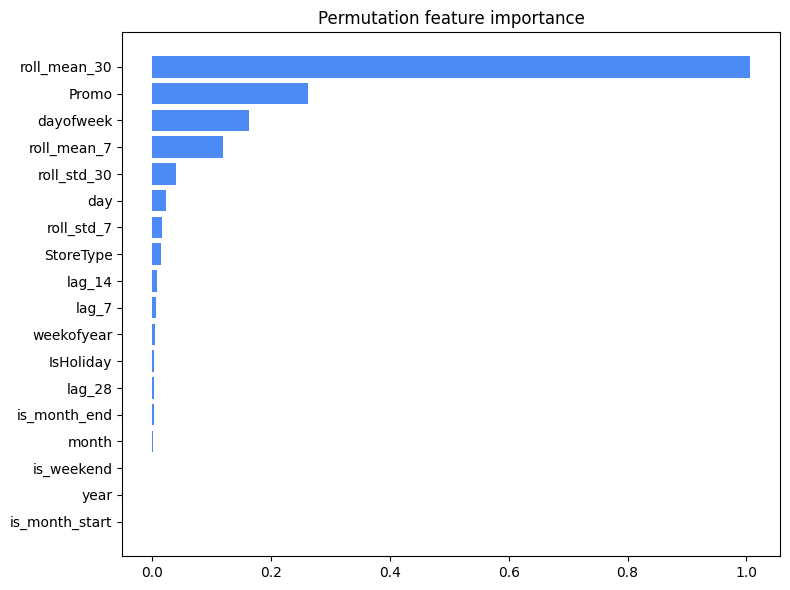

Top 5 drivers: roll_mean_30, Promo, dayofweek, roll_mean_7, roll_std_30


In [8]:
# permutation importance on a validation sample (model-agnostic, the "correct" importance)
samp = valid.sample(min(5000, len(valid)), random_state=42)
pi = permutation_importance(model, samp[FEATURES], samp.Sales,
                            n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
plt.figure(figsize=(8,6))
plt.barh(imp.index, imp.values, color="#4C8BF5")
plt.title("Permutation feature importance"); plt.tight_layout(); plt.show()
print("Top 5 drivers:", ", ".join(imp.sort_values(ascending=False).index[:5]))

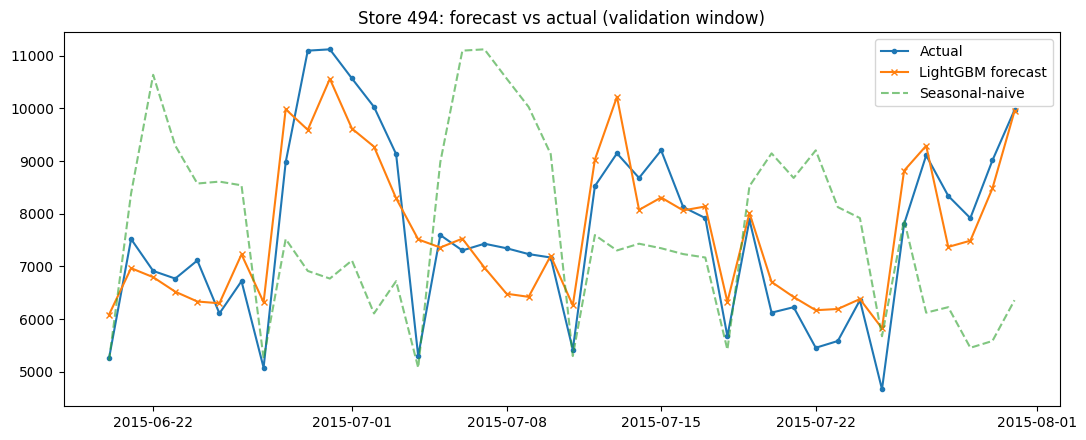

In [9]:
sid = valid.Store.value_counts().index[0]
sv = valid[valid.Store == sid].sort_values("Date")
svp = np.clip(model.predict(sv[FEATURES]), 0, None)
plt.figure(figsize=(11,4.5))
plt.plot(sv.Date, sv.Sales, marker="o", ms=3, label="Actual")
plt.plot(sv.Date, svp, marker="x", ms=4, label="LightGBM forecast")
plt.plot(sv.Date, sv.lag_7, ls="--", alpha=.6, label="Seasonal-naive")
plt.title(f"Store {sid}: forecast vs actual (validation window)")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Notes & next steps

- **No leakage:** features are past-only and the split is by time — the validation score is
  a fair estimate of forecasting the genuine future.
- **Beating the baseline is the point.** Report the % improvement, not just the raw error.
- **Where to take it further:** add store-level promos-this-week counts, encode school/state
  holidays, try a per-store global model vs. clustered models, or compare against LightGBM or an LSTM to
  show you know when deep learning does / doesn't help on tabular data.